# Source Far-Field Projection

Standalone diagnostic notebook.  Builds the same two Gaussian source simulations
as the **Source Verification** section of `overlapping_inputs.ipynb`, runs them
(or loads cached HDF5), then projects the captured near-field to a Cartesian plane
at **100 µm** using `td.FieldProjector`.

Expected result: Source A (φ = +2°) peaks at **y ≈ +3.5 µm** and
Source B (φ = −2°) peaks at **y ≈ −3.5 µm**, separated by ~7 µm.

## Imports

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import tidy3d.web as web

## Configuration

Mirrors `overlapping_inputs.ipynb` cells 3 and 6 exactly.

In [2]:
# Geometric parameters.
w_thick     = 0.22      # Waveguide thickness (um).
w_width     = 0.5       # Waveguide width (um).
w_length    = 1.0       # Waveguide length (um).
box_thick   = 0.752     # SiO2 BOX thickness (um).
fiber_tilt  = 10.0      # Fiber tilt angle in xz plane (degrees).
src_offset  = 0.05      # Distance between source focus and device surface (um).

# Material.
nSiO2   = 1.44
nSi3N4  = 2.03

# Design region — matches overlapping_inputs.ipynb.
gc_width        = 15.0          # Grating coupler width PER CHANNEL (um).
gc_width_total  = 2 * gc_width  # Total y-extent = 30.0 um.
gc_length       = 8.0           # Grating coupler length in x (um).
dr_grid_size    = 0.02          # Grid size within the design region (um).

# Simulation wavelength.
wl  = 0.729   # Central wavelength (um).
bw  = 0.02    # Bandwidth (um).
n_wl = 10     # Wavelength points in bandwidth.

# Fabrication / filter.
border_buffer = 0.16

In [3]:
# Permittivities.
eps_max = nSi3N4**2
eps_min = 1.0

# Materials.
mat_sio2  = td.Medium(permittivity=nSiO2**2)
mat_si3n4 = td.Medium(permittivity=eps_max)

# Frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq  = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])
run_time = 5e-12

# Waveguide y-centres (symmetric about y=0).
y_center_top =  gc_width / 2   # +1.5 um
y_center_bot = -gc_width / 2   # -1.5 um

# Source angles.
xz_rad    = np.radians(fiber_tilt)
yz_rad    = np.arctan(3.5 / 100)          # ≈ 2.006° — puts far-field peaks ±3.5 µm at 100 µm
theta_src = float(np.arcsin(np.sqrt(np.sin(xz_rad)**2 + np.sin(yz_rad)**2)))
phi_A     =  float(np.arctan2(np.sin(yz_rad), np.sin(xz_rad)))  # Source A: +yz tilt
phi_B     = -phi_A                                                # Source B: -yz tilt

print(f"YZ tilt angle : {np.degrees(yz_rad):.3f}°")
print(f"theta_src     : {np.degrees(theta_src):.3f}°")
print(f"phi_A         : {np.degrees(phi_A):.3f}°  (Source A)")
print(f"phi_B         : {np.degrees(phi_B):.3f}°  (Source B)")

# Computational domain.
pml_spacing = 0.6 * wl
size_x = pml_spacing + w_length + gc_length + 2 * border_buffer
size_y = gc_width_total + 2 * pml_spacing + 2 * border_buffer
size_z = w_thick + box_thick + 2 * pml_spacing
center_z = size_z / 2 - pml_spacing - w_thick / 2
eff_inf = 1000

# Source position.
src_pos_z = w_thick / 2 + src_offset

# Design region derived dimensions.
nx        = int((gc_length      + 2 * border_buffer) / dr_grid_size)
ny        = int((gc_width_total + 2 * border_buffer) / dr_grid_size)
dr_size_x = nx * dr_grid_size
dr_size_y = ny * dr_grid_size
dr_center_x = -size_x / 2 + w_length + dr_size_x / 2

# Source aperture sizes.
source_size_x = dr_size_x - 2 * border_buffer
source_size_y = dr_size_y - 2 * border_buffer

print(f"\nDesign region  : {dr_size_x:.2f} µm × {dr_size_y:.2f} µm")
print(f"Grid nx × ny   : {nx} × {ny} = {nx*ny:,} parameters")
print(f"src_pos_z      : {src_pos_z:.3f} µm  (source launch plane)")
print(f"monitor z      : {w_thick:.3f} µm  (source_test_monitor / field_near_src)")

YZ tilt angle : 2.005°
theta_src     : 10.203°
phi_A         : 11.389°  (Source A)
phi_B         : -11.389°  (Source B)

Design region  : 8.32 µm × 30.32 µm
Grid nx × ny   : 416 × 1516 = 630,656 parameters
src_pos_z      : 0.160 µm  (source launch plane)
monitor z      : 0.220 µm  (source_test_monitor / field_near_src)


## Structures and Sources

Mirrors `overlapping_inputs.ipynb` cell 8.  The design region is a uniform Si3N4 slab
(no CustomMedium needed — source verification is independent of the design pattern).

In [4]:
# Waveguides.
waveguide_top = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, y_center_top - w_width/2, -w_thick/2),
        rmax=(-size_x/2 + w_length, y_center_top + w_width/2,  w_thick/2),
    ),
    medium=mat_si3n4,
)
waveguide_bot = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, y_center_bot - w_width/2, -w_thick/2),
        rmax=(-size_x/2 + w_length, y_center_bot + w_width/2,  w_thick/2),
    ),
    medium=mat_si3n4,
)

# SiO2 BOX layer.
sio2_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -w_thick/2 - box_thick),
        rmax=( eff_inf,  eff_inf, -w_thick/2),
    ),
    medium=mat_sio2,
)

# Si3N4 substrate.
si3n4_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, -eff_inf),
        rmax=( eff_inf,  eff_inf, -w_thick/2 - box_thick),
    ),
    medium=mat_si3n4,
)

# Uniform Si3N4 slab in place of the design region.
# (Source verification does not depend on design pattern.)
design_region_slab = td.Structure(
    geometry=td.Box(
        center=(dr_center_x, 0, 0),
        size=(dr_size_x, dr_size_y, w_thick),
    ),
    medium=mat_si3n4,
)

# --- Optimal waist sizes: same closed-form formula as overlapping_inputs.ipynb ---
#
# Tilted beam footprint on z=const source plane projected to get waist sizes:
#   wx = sqrt( (cos²φ·Lx² - sin²φ·Ly²) / (n²·cos²θ·cos2φ) )
#   wy = sqrt( (cos²φ·Ly² - sin²φ·Lx²) / (n²·cos2φ) )
# n=2: the 2·w₀ contour just reaches the aperture edge.
_n       = 2.0
_Lx      = source_size_x / 2
_Ly      = source_size_y / 2
_cp2     = np.cos(phi_A) ** 2
_sp2     = np.sin(phi_A) ** 2
_ct2     = np.cos(theta_src) ** 2
_cos2phi = np.cos(2 * phi_A)
waist_x  = float(np.sqrt((_cp2 * _Lx**2 - _sp2 * _Ly**2) / (_n**2 * _ct2 * _cos2phi)))
waist_y  = float(np.sqrt((_cp2 * _Ly**2 - _sp2 * _Lx**2) / (_n**2 * _cos2phi)))
print(f"waist_x = {waist_x:.4f} µm")
print(f"waist_y = {waist_y:.4f} µm")

# Source A: +YZ tilt  →  far-field peak at y ≈ +3.5 µm @ 100 µm.
gauss_A = td.AstigmaticGaussianBeam(
    center=(dr_center_x, 0, src_pos_z),
    size=(source_size_x, source_size_y, 0),
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
    pol_angle=np.pi / 2,
    angle_theta=theta_src,
    angle_phi=phi_A,
    direction="-",
    num_freqs=7,
    waist_sizes=(waist_x, waist_y),
    waist_distances=(0, 0),
)

# Source B: -YZ tilt  →  far-field peak at y ≈ -3.5 µm @ 100 µm.
gauss_B = td.AstigmaticGaussianBeam(
    center=(dr_center_x, 0, src_pos_z),
    size=(source_size_x, source_size_y, 0),
    source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
    pol_angle=np.pi / 2,
    angle_theta=theta_src,
    angle_phi=phi_B,
    direction="-",
    num_freqs=7,
    waist_sizes=(waist_x, waist_y),
    waist_distances=(0, 0),
)

all_structures = [waveguide_top, waveguide_bot, sio2_substrate, si3n4_substrate, design_region_slab]

waist_x = 1.3595 µm
waist_y = 7.6459 µm


## Monitor Definitions

Two monitors are added to each simulation:

- **`source_test_monitor`** — full-domain field snapshot at `z = w_thick`.
  Same as the original Source Verification section; used for the near-field
  sanity-check plot only.

- **`field_near_src`** — same `z` plane but sized to the design-region
  aperture + 1 µm buffer on each side.  Fields within the PML are artificial
  (absorbing medium) and corrupt the Huygens surface integral inside
  `FieldProjector`, so this clipped monitor is used for the far-field
  projection.

In [5]:
# Full-domain display monitor (for near-field plot).
source_test_monitor = td.FieldMonitor(
    center=(dr_center_x, 0, w_thick),
    size=(size_x, size_y, 0),
    name="source_test_monitor",
    freqs=[freq],
)

# Clipped near-field monitor for far-field projection (non-PML region only).
field_near_src = td.FieldMonitor(
    center=(dr_center_x, 0, w_thick),
    size=(dr_size_x + 2.0, dr_size_y + 2.0, 0),
    freqs=[freq],
    name="field_near_src",
)

## Far-Field Cartesian Monitor

Projects along `z` (`proj_axis=2`) to a plane 100 µm above the near-field monitor.
The y grid is wide enough (±10 µm) to capture both expected far-field lobes at ±3.5 µm.

In [6]:
r_proj = 100.0  # projection distance (um)

# Projection grid — centred on the design region in x, symmetric in y.
x_proj = np.linspace(-40, 10, 100)    # ±8 µm around dr_center_x
y_proj = np.linspace(-30, 30, 200)  # ±10 µm (captures ±3.5 µm lobes with margin)

monitor_far = td.FieldProjectionCartesianMonitor(
    center=field_near_src.center,
    size=(td.inf, td.inf, 0),
    freqs=[freq],
    name="far_field",
    proj_axis=2,
    proj_distance=r_proj,
    x=list(x_proj + dr_center_x),
    y=list(y_proj),
    far_field_approx=True,
    colocate=True,
)

print(f"Far-field monitor: x in [{x_proj[0]+dr_center_x:.1f}, {x_proj[-1]+dr_center_x:.1f}] µm, "
      f"y in [{y_proj[0]:.1f}, {y_proj[-1]:.1f}] µm  @  z = {r_proj:.0f} µm")

Far-field monitor: x in [-39.7, 10.3] µm, y in [-30.0, 30.0] µm  @  z = 100 µm


## Build Simulations

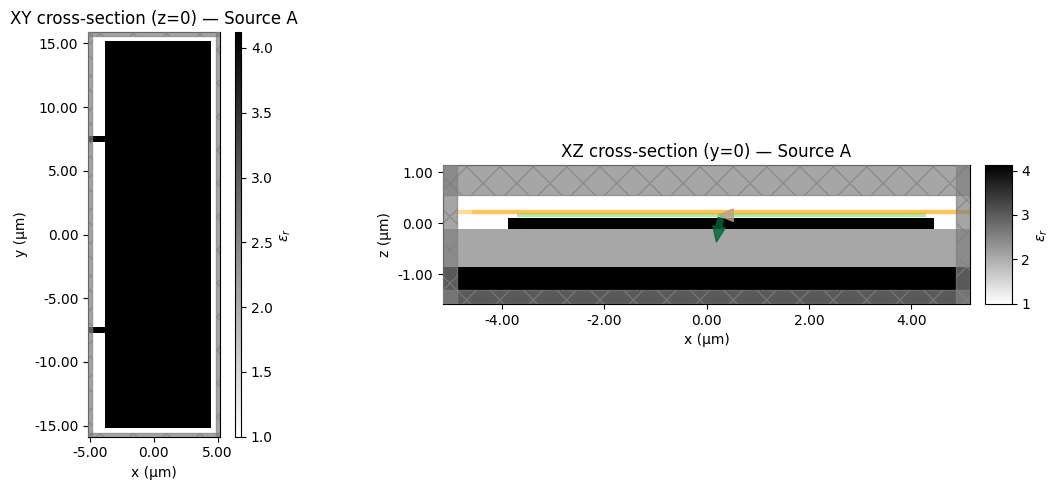

In [7]:
def make_source_test_sim(source: str) -> td.Simulation:
    """Build source-test simulation for 'A' or 'B'.

    Includes both the full-domain display monitor and the clipped
    near-field monitor suitable for far-field projection.
    """
    src = gauss_A if source == "A" else gauss_B
    return td.Simulation(
        size=[size_x, size_y, size_z],
        center=[0, 0, -center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=wl_max,
            min_steps_per_wvl=15,
        ),
        symmetry=(0, 0, 0),
        structures=all_structures,
        sources=[src],
        monitors=[source_test_monitor, field_near_src],
        run_time=run_time,
        subpixel=True,
    )


sim_src_A = make_source_test_sim("A")
sim_src_B = make_source_test_sim("B")

# Quick cross-section plot to confirm geometry before running.
fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(12, 5))
sim_src_A.plot_eps(z=0, ax=ax1)
ax1.set_title("XY cross-section (z=0) — Source A")
sim_src_A.plot_eps(y=0, ax=ax2)
ax2.set_title("XZ cross-section (y=0) — Source A")
plt.show()

## Run or Load

Results are saved to `data/source_test_A.hdf5` / `data/source_test_B.hdf5`.
Re-running the cell will load from disk if those files already exist, avoiding
unnecessary FlexCredit consumption.

In [8]:
path_A = "data/source_test_A.hdf5"
path_B = "data/source_test_B.hdf5"

if os.path.exists(path_A) and os.path.exists(path_B):
    data_src_A = td.SimulationData.from_file(path_A)
    data_src_B = td.SimulationData.from_file(path_B)
    print("Loaded saved source test data from disk.")
else:
    job_A = web.Job(simulation=sim_src_A, task_name="source_farfield_A")
    job_B = web.Job(simulation=sim_src_B, task_name="source_farfield_B")
    print(f"Estimated cost A : {web.estimate_cost(job_A.task_id):.3f} FlexCredits")
    print(f"Estimated cost B : {web.estimate_cost(job_B.task_id):.3f} FlexCredits")
    data_src_A = job_A.run(path=path_A)
    data_src_B = job_B.run(path=path_B)

Loaded saved source test data from disk.


## Near-Field Sanity Check

Reproduces the original Source Verification plot from `overlapping_inputs.ipynb`.
Both beams should show the same spatial footprint centred at y = 0,
differing only in their fringe orientation.

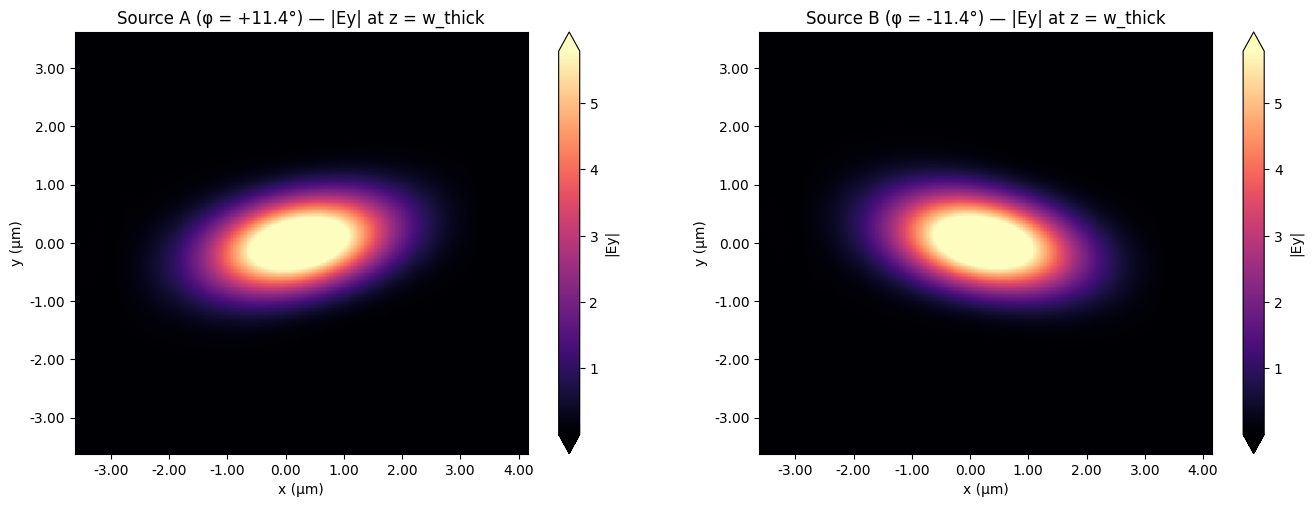

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)
data_src_A.plot_field("source_test_monitor", "Ey", "abs", ax=axes[0])
axes[0].set_title(f"Source A (φ = +{np.degrees(phi_A):.1f}°) — |Ey| at z = w_thick")
data_src_B.plot_field("source_test_monitor", "Ey", "abs", ax=axes[1])
axes[1].set_title(f"Source B (φ = {np.degrees(phi_B):.1f}°) — |Ey| at z = w_thick")
plt.show()

## Far-Field Projection

`FieldProjector.from_near_field_monitors` constructs a Huygens surface from
`field_near_src` (the clipped monitor) and integrates to the Cartesian plane
defined by `monitor_far`.  `normal_dirs=["+"]` projects in the +z direction
(upward, away from the substrate).

In [10]:
def project_far_field(sim_data: td.SimulationData) -> td.FieldProjectionCartesianData:
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=sim_data,
        near_monitors=[field_near_src],
        normal_dirs=["+"],
        pts_per_wavelength=10,
    )
    return projector.project_fields(monitor_far)


print("Projecting Source A...")
proj_A = project_far_field(data_src_A)
print("Projecting Source B...")
proj_B = project_far_field(data_src_B)
print("Done.")

Projecting Source A...


21:18:11 PDT WARNING: Colocating data that has already been colocated during the
             solver run. For most accurate results when colocating to custom    
             coordinates set 'Monitor.colocate' to 'False' to use the raw data  
             on the Yee grid and avoid double interpolation. Note: the default  
             value was changed to 'True' in Tidy3D version 2.4.0.               

ValueError: A value (-4.164414285714285) in x_new is below the interpolation range's minimum value (-3.902509523809524).

## Far-Field Intensity Plot

Total intensity `|E_θ|² + |E_φ|²` at 100 µm.  White dashed lines mark the
expected beam-centre positions (±3.5 µm) derived from the source angle geometry.

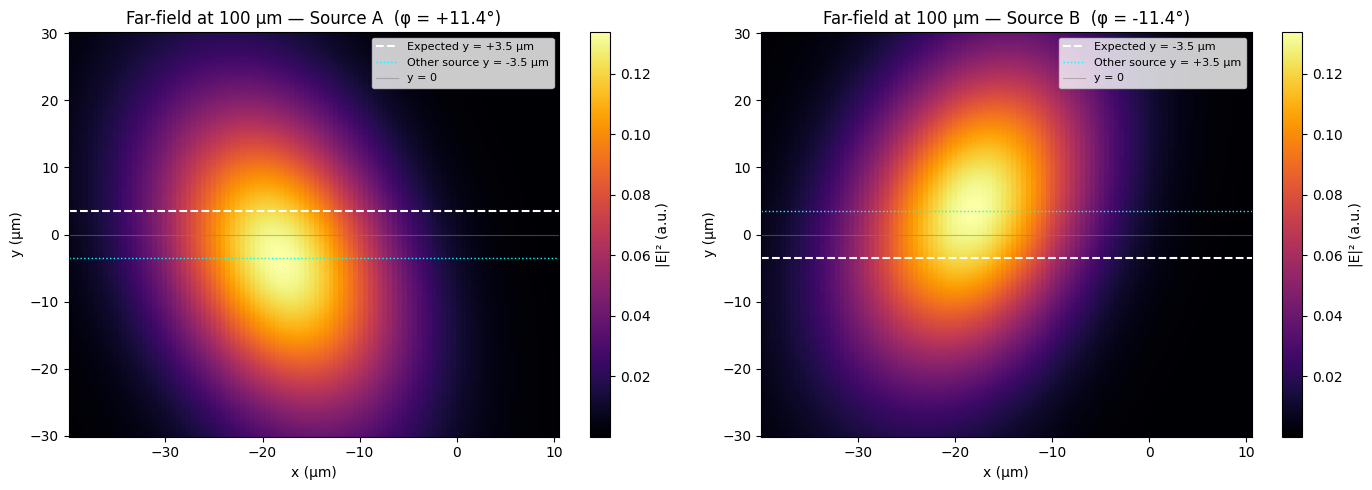

In [ ]:
def intensity(proj: td.FieldProjectionCartesianData) -> np.ndarray:
    """Total |E|² from far-field projection data."""
    E_theta = proj.Etheta.isel(f=0).values.squeeze()
    E_phi   = proj.Ephi.isel(f=0).values.squeeze()
    return np.abs(E_theta)**2 + np.abs(E_phi)**2


def beam_center_y(I: np.ndarray) -> float:
    """Intensity-weighted mean y coordinate (centroid)."""
    return float(np.sum(I * y_proj[np.newaxis, :]) / np.sum(I))


I_A = intensity(proj_A)
I_B = intensity(proj_B)

y_A_expected =  3.5   # um
y_B_expected = -3.5   # um

fig, axes = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)
for ax, I, title, y_exp, y_other in zip(
    axes,
    [I_A, I_B],
    [f"Source A  (φ = +{np.degrees(phi_A):.1f}°)", f"Source B  (φ = {np.degrees(phi_B):.1f}°)"],
    [y_A_expected, y_B_expected],
    [y_B_expected, y_A_expected],
):
    im = ax.pcolormesh(x_proj + dr_center_x, y_proj, I.T, shading="auto", cmap="inferno")
    fig.colorbar(im, ax=ax, label="|E|² (a.u.)")
    ax.axhline(y_exp,   color="white", ls="--", lw=1.5, label=f"Expected y = {y_exp:+.1f} µm")
    ax.axhline(y_other, color="cyan",  ls=":",  lw=1.0, label=f"Other source y = {y_other:+.1f} µm")
    ax.axhline(0,       color="gray",  ls="-",  lw=0.8, alpha=0.5, label="y = 0")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"Far-field at {r_proj:.0f} µm — {title}")

plt.show()

## Quantitative Summary

In [ ]:
y_A_meas = beam_center_y(I_A)
y_B_meas = beam_center_y(I_B)
sep_meas = y_A_meas - y_B_meas

print("=" * 55)
print(f"Far-field beam centres at {r_proj:.0f} µm")
print("=" * 55)
print(f"  Source A centroid : y = {y_A_meas:+.2f} µm  (target {y_A_expected:+.1f} µm)")
print(f"  Source B centroid : y = {y_B_meas:+.2f} µm  (target {y_B_expected:+.1f} µm)")
print(f"  Measured separation : {sep_meas:.2f} µm  (target 7.00 µm)")
print(f"  Source A error      : {abs(y_A_meas - y_A_expected):.2f} µm")
print(f"  Source B error      : {abs(y_B_meas - y_B_expected):.2f} µm")

Far-field beam centres at 100 µm
  Source A centroid : y = -2.60 µm  (target +3.5 µm)
  Source B centroid : y = +2.60 µm  (target -3.5 µm)
  Measured separation : -5.19 µm  (target 7.00 µm)
  Source A error      : 6.10 µm
  Source B error      : 6.10 µm
